In [1]:
# ==========================================================
# Handwritten Formula Recognition
# Cell 1 - Imports
# ==========================================================

import os
import json
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import transforms
from torchvision.models import efficientnet_b0

warnings.filterwarnings("ignore")

In [2]:
# ==========================================================
# Cell 2 - Configuration
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
torch.backends.cudnn.benchmark = True

print("=" * 60)
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
print("Device  :", DEVICE)

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
    print("VRAM    :",
          round(torch.cuda.get_device_properties(0).total_memory/1024**3,2),
          "GB")

print("=" * 60)

PyTorch : 2.11.0+cu128
CUDA    : True
Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM    : 6.0 GB


In [3]:
# ==========================================================
# Cell 3 - Dataset Paths
# ==========================================================

ROOT_DIR = Path("dataset/HME100K")

TRAIN_IMAGE_DIR = ROOT_DIR / "train" / "train_images"
TRAIN_LABEL_FILE = ROOT_DIR / "train" / "train_labels.txt"

TEST_IMAGE_DIR = ROOT_DIR / "test" / "test_images"
TEST_LABEL_FILE = ROOT_DIR / "test" / "test_labels.txt"

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

print("Train Images :", TRAIN_IMAGE_DIR)
print("Train Labels :", TRAIN_LABEL_FILE)
print("Test Images  :", TEST_IMAGE_DIR)
print("Test Labels  :", TEST_LABEL_FILE)

Train Images : dataset\HME100K\train\train_images
Train Labels : dataset\HME100K\train\train_labels.txt
Test Images  : dataset\HME100K\test\test_images
Test Labels  : dataset\HME100K\test\test_labels.txt


In [38]:
# ==========================================================
# Cell 4 - Hyperparameters
# ==========================================================

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 512
BATCH_SIZE = 48

NUM_WORKERS = 0

EPOCHS = 50

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

EMBED_DIM = 256

NUM_HEADS = 8

NUM_LAYERS = 4

DROPOUT = 0.1

MAX_FORMULA_LENGTH = 128

SAVE_EVERY = 10

PATIENCE = 10

In [39]:
# ==========================================================
# Cell 5 - Read Labels
# ==========================================================

train_data = []

with open(TRAIN_LABEL_FILE, "r", encoding="utf-8") as f:

    for line in tqdm(f, desc="Reading Train Labels"):

        line = line.strip()

        if not line:
            continue

        parts = line.split("\t")

        if len(parts) != 2:
            continue

        image_name, formula = parts

        image_path = TRAIN_IMAGE_DIR / image_name

        if image_path.exists():

            train_data.append({
                "image": str(image_path),
                "formula": formula
            })

train_df = pd.DataFrame(train_data)

print("=" * 60)
print("Total Training Samples :", len(train_df))
print("=" * 60)

train_df.head()

Reading Train Labels: 0it [00:00, ?it/s]

Total Training Samples : 74502


,image,formula
0,dataset\HME100K\train\train_images\train_0.jpg,( 2 ) 2 N a O H + C u S O _ { 4 } = N a _ { 2 ...
1,dataset\HME100K\train\train_images\train_2.jpg,\angle A C B = \angle A ^ { \prime } C B ^ { \...
2,dataset\HME100K\train\train_images\train_3.jpg,1 0 \times ( x + 5 ) = 1 3 \times ( \frac { 5 ...
3,dataset\HME100K\train\train_images\train_4.jpg,l _ { 2 } = O B = \frac { O A } { 4 } \times 3...
4,dataset\HME100K\train\train_images\train_6.jpg,\angle A = 4 0 ^ { \circ }


In [40]:
# ==========================================================
# Cell 6 - Read Test Labels
# ==========================================================

test_data = []

with open(TEST_LABEL_FILE, "r", encoding="utf-8") as f:

    for line in tqdm(f, desc="Reading Test Labels"):

        line = line.strip()

        if not line:
            continue

        parts = line.split("\t")

        if len(parts) != 2:
            continue

        image_name, formula = parts

        image_path = TEST_IMAGE_DIR / image_name

        if image_path.exists():

            test_data.append({
                "image": str(image_path),
                "formula": formula
            })

test_df = pd.DataFrame(test_data)

print("=" * 60)
print("Total Test Samples :", len(test_df))
print("=" * 60)

test_df.head()

Reading Test Labels: 0it [00:00, ?it/s]

Total Test Samples : 24607


,image,formula
0,dataset\HME100K\test\test_images\test_2.jpg,\frac { 5 } { 1 4 } = \frac { 1 } { x }
1,dataset\HME100K\test\test_images\test_3.jpg,- 2 x ^ { 4 } - x ^ { 2 } + 5 = ( - x ^ { 2 } ...
2,dataset\HME100K\test\test_images\test_5.jpg,S _ { \Delta D B F } = \frac { 3 } { 8 } S _ {...
3,dataset\HME100K\test\test_images\test_6.jpg,: x _ { 1 } = - \frac { 3 } { 5 }
4,dataset\HME100K\test\test_images\test_7.jpg,7 5 \div ( 7 5 + 2 5 ) = 7 5 \div 1 0 0 = 7 5 \%


In [41]:
# ==========================================================
# Cell 7 - Train / Validation Split
# ==========================================================

train_df, valid_df = train_test_split(
    train_df,
    test_size=0.10,
    random_state=SEED,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print("=" * 60)
print("Training Samples  :", len(train_df))
print("Validation Samples:", len(valid_df))
print("Test Samples      :", len(test_df))
print("=" * 60)

Training Samples  : 67051
Validation Samples: 7451
Test Samples      : 24607


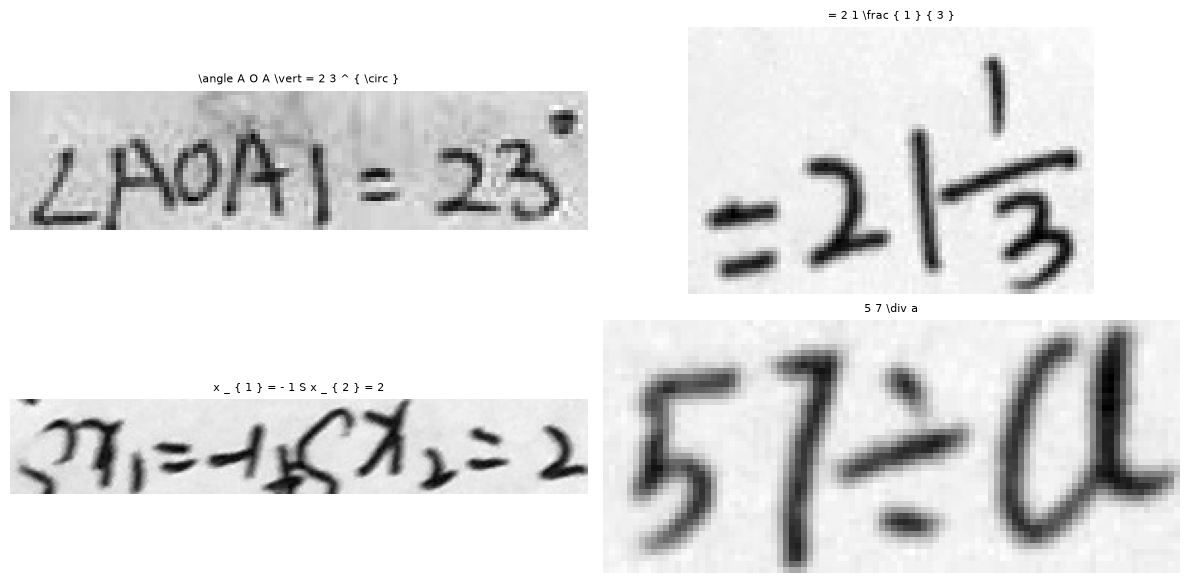

In [42]:
# ==========================================================
# Cell 8 - Visualize Samples
# ==========================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

samples = train_df.sample(4, random_state=SEED).reset_index(drop=True)

for ax, (_, row) in zip(axes.flatten(), samples.iterrows()):

    img = Image.open(row["image"]).convert("L")

    ax.imshow(img, cmap="gray")
    ax.set_title(row["formula"][:80], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [43]:
# ==========================================================
# Cell 9 - Vocabulary
# ==========================================================

from collections import Counter


class Vocabulary:

    def __init__(self, min_freq=1):

        self.min_freq = min_freq

        self.special_tokens = [
            "<PAD>",
            "<SOS>",
            "<EOS>",
            "<UNK>"
        ]

        self.token2idx = {}
        self.idx2token = {}

    def build(self, formulas):

        counter = Counter()

        for formula in formulas:

            tokens = formula.split()

            counter.update(tokens)

        vocab_tokens = [
            token
            for token, freq in counter.items()
            if freq >= self.min_freq
        ]

        all_tokens = self.special_tokens + sorted(vocab_tokens)

        self.token2idx = {
            token: idx
            for idx, token in enumerate(all_tokens)
        }

        self.idx2token = {
            idx: token
            for token, idx in self.token2idx.items()
        }

    def encode(self, formula):

        tokens = formula.split()

        encoded = [
            self.token2idx["<SOS>"]
        ]

        for token in tokens:

            encoded.append(
                self.token2idx.get(
                    token,
                    self.token2idx["<UNK>"]
                )
            )

        encoded.append(
            self.token2idx["<EOS>"]
        )

        return encoded

    def decode(self, indices):

        tokens = []

        for idx in indices:

            token = self.idx2token.get(
                idx,
                "<UNK>"
            )

            if token == "<EOS>":
                break

            if token not in [
                "<SOS>",
                "<PAD>"
            ]:
                tokens.append(token)

        return " ".join(tokens)

    def __len__(self):

        return len(self.token2idx)

In [44]:
# ==========================================================
# Cell 10 - Build Vocabulary
# ==========================================================

vocab = Vocabulary(min_freq=1)

vocab.build(train_df["formula"])

print("=" * 60)
print("Vocabulary Size :", len(vocab))
print("=" * 60)

print("\nFirst 30 Tokens:\n")

for i in range(min(30, len(vocab))):
    print(i, "->", vocab.idx2token[i])

Vocabulary Size : 241

First 30 Tokens:

0 -> <PAD>
1 -> <SOS>
2 -> <EOS>
3 -> <UNK>
4 -> !
5 -> "
6 -> %
7 -> (
8 -> )
9 -> +
10 -> ,
11 -> -
12 -> .
13 -> /
14 -> 0
15 -> 1
16 -> 2
17 -> 3
18 -> 4
19 -> 5
20 -> 6
21 -> 7
22 -> 8
23 -> 9
24 -> :
25 -> ;
26 -> <
27 -> =
28 -> >
29 -> ?


In [45]:
# ==========================================================
# Cell 11 - Test Vocabulary
# ==========================================================

sample_formula = train_df.iloc[0]["formula"]

print("Original:\n")
print(sample_formula)

encoded = vocab.encode(sample_formula)

print("\nEncoded:\n")
print(encoded)

decoded = vocab.decode(encoded)

print("\nDecoded:\n")
print(decoded)

Original:

C M = \frac { 3 } { 2 }

Encoded:

[1, 32, 42, 27, 96, 182, 17, 183, 182, 16, 183, 2]

Decoded:

C M = \frac { 3 } { 2 }


In [46]:
# ==========================================================
# Cell 12 - Resize while keeping aspect ratio
# ==========================================================

from PIL import ImageOps

def resize_with_padding(image, target_size=(512, 128)):

    target_w, target_h = target_size

    w, h = image.size

    scale = min(target_w / w, target_h / h)

    new_w = int(w * scale)
    new_h = int(h * scale)

    image = image.resize(
        (new_w, new_h),
        Image.Resampling.LANCZOS
    )

    canvas = Image.new(
        "RGB",
        (target_w, target_h),
        (255, 255, 255)
    )

    left = (target_w - new_w) // 2
    top = (target_h - new_h) // 2

    canvas.paste(image, (left, top))

    return canvas

In [47]:
# ==========================================================
# Cell 13 - Image Transform
# ==========================================================

train_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

valid_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

print("Transforms Ready")

Transforms Ready


In [48]:
# ==========================================================
# Cell 14 - Formula Dataset
# ==========================================================

class FormulaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        vocab,
        transform=None
    ):

        self.dataframe = dataframe

        self.vocab = vocab

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(
            row["image"]
        ).convert("RGB")

        image = resize_with_padding(
            image,
            (IMAGE_WIDTH, IMAGE_HEIGHT)
        )

        if self.transform:

            image = self.transform(image)

        formula = self.vocab.encode(
            row["formula"]
        )

        return image, torch.tensor(
            formula,
            dtype=torch.long
        )

In [49]:
# ==========================================================
# Cell 15 - Collate Function
# ==========================================================

from torch.nn.utils.rnn import pad_sequence

PAD_IDX = vocab.token2idx["<PAD>"]

def collate_fn(batch):

    images = []

    formulas = []

    lengths = []

    for image, formula in batch:

        images.append(image)

        formulas.append(formula)

        lengths.append(len(formula))

    images = torch.stack(images)

    formulas = pad_sequence(
        formulas,
        batch_first=True,
        padding_value=PAD_IDX
    )

    lengths = torch.tensor(lengths)

    return images, formulas, lengths

print("Collate Function Ready")

Collate Function Ready


In [50]:
# ==========================================================
# Cell 16 - Dataset Objects
# ==========================================================

train_dataset = FormulaDataset(

    train_df,

    vocab,

    train_transform
)

valid_dataset = FormulaDataset(

    valid_df,

    vocab,

    valid_transform
)

test_dataset = FormulaDataset(

    test_df,

    vocab,

    valid_transform
)

print("Train :", len(train_dataset))
print("Valid :", len(valid_dataset))
print("Test  :", len(test_dataset))

Train : 67051
Valid : 7451
Test  : 24607


In [51]:
# ==========================================================
# Cell 17 - DataLoaders
# ==========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True,
)

print("="*60)
print("Train batches :", len(train_loader))
print("Valid batches :", len(valid_loader))
print("Test batches  :", len(test_loader))
print("="*60)

Train batches : 1397
Valid batches : 156
Test batches  : 513


In [52]:
# ==========================================================
# Cell 18 - Verify DataLoader
# ==========================================================

images, formulas, lengths = next(iter(train_loader))

print("Images Shape   :", images.shape)
print("Formula Shape  :", formulas.shape)
print("Lengths Shape  :", lengths.shape)

print("Max Formula Length :", formulas.shape[1])

Images Shape   : torch.Size([48, 3, 128, 512])
Formula Shape  : torch.Size([48, 43])
Lengths Shape  : torch.Size([48])
Max Formula Length : 43


In [53]:
# ==========================================================
# Cell 19 - EfficientNet Encoder
# ==========================================================

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

class Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )

        self.features = backbone.features

        self.pool = nn.AdaptiveAvgPool2d((8,32))

        self.projection = nn.Conv2d(
            1280,
            EMBED_DIM,
            kernel_size=1
        )

    def forward(self,x):

        x = self.features(x)

        x = self.pool(x)

        x = self.projection(x)

        B,C,H,W = x.shape

        x = x.flatten(2)

        x = x.permute(2,0,1)

        return x

In [54]:
# ==========================================================
# Cell 20 - Positional Encoding
# ==========================================================

import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, dropout=0.1, max_len=5000):

        super().__init__()

        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)        # (1, max_len, d_model)

        self.register_buffer("pe", pe)

    def forward(self, x):

        x = x + self.pe[:, :x.size(1)]

        return self.dropout(x)

In [55]:
# ==========================================================
# Cell 21 - Transformer Decoder
# ==========================================================

class Decoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(
            len(vocab),
            EMBED_DIM,
            padding_idx=PAD_IDX
        )

        self.position = PositionalEncoding(
            EMBED_DIM,
            DROPOUT
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=EMBED_DIM,
            nhead=NUM_HEADS,
            dim_feedforward=1024,
            dropout=DROPOUT,
            batch_first=True
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=NUM_LAYERS
        )

        self.fc = nn.Linear(
            EMBED_DIM,
            len(vocab)
        )

    def forward(
        self,
        memory,
        tgt,
        tgt_mask=None,
        tgt_padding_mask=None
    ):

        tgt = self.embedding(tgt)

        tgt = self.position(tgt)

        out = self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_padding_mask
        )

        out = self.fc(out)

        return out

In [56]:
# ==========================================================
# Cell 22 - EfficientNet Encoder
# ==========================================================

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

class Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )

        self.features = backbone.features

        self.pool = nn.AdaptiveAvgPool2d((4, 16))

        self.projection = nn.Conv2d(
            1280,
            EMBED_DIM,
            kernel_size=1
        )

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = self.projection(x)

        B, C, H, W = x.shape

        x = x.flatten(2)              # (B,C,64)

        x = x.transpose(1, 2)         # (B,64,C)

        return x

In [57]:
# ==========================================================
# Cell 23 - Formula Recognizer
# ==========================================================

class FormulaRecognizer(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = Encoder()

        self.decoder = Decoder()

    def forward(
        self,
        images,
        tgt,
        tgt_mask=None,
        tgt_padding_mask=None
    ):

        memory = self.encoder(images)

        return self.decoder(
            memory,
            tgt,
            tgt_mask,
            tgt_padding_mask
        )


model = FormulaRecognizer().to(DEVICE)



print(model)

print("\nDevice:", next(model.parameters()).device)

FormulaRecognizer(
  (encoder): Encoder(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_

In [58]:
# ==========================================================
# Cell 24 - Causal Mask
# ==========================================================

def create_causal_mask(seq_len):

    mask = torch.triu(
        torch.ones(seq_len, seq_len, device=DEVICE),
        diagonal=1
    )

    mask = mask.masked_fill(mask == 1, float("-inf"))

    return mask

In [59]:
# ==========================================================
# Cell 25 - Loss, Optimizer & Scheduler
# ==========================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

print("Training Components Ready")

Training Components Ready


In [60]:
# ==========================================================
# Cell 26 - Metrics
# ==========================================================

@torch.no_grad()
def token_accuracy(outputs, targets):

    preds = outputs.argmax(dim=-1)

    mask = targets != PAD_IDX

    correct = ((preds == targets) & mask).sum().item()

    total = mask.sum().item()

    return 100 * correct / total


@torch.no_grad()
def exact_match_accuracy(outputs, targets):

    preds = outputs.argmax(dim=-1)

    batch_size = targets.size(0)

    correct = 0

    for i in range(batch_size):

        mask = targets[i] != PAD_IDX

        if torch.equal(
            preds[i][mask],
            targets[i][mask]
        ):
            correct += 1

    return 100 * correct / batch_size

In [61]:
# ==========================================================
# Cell 27 - Train One Epoch
# ==========================================================

from tqdm.auto import tqdm


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler
):

    model.train()

    total_loss = 0
    total_token = 0
    total_exact = 0

    progress = tqdm(
        loader,
        desc="Training"
    )

    for images, formulas, lengths in progress:

        images = images.to(
    DEVICE,
    non_blocking=True
)
        formulas = formulas.to(DEVICE, non_blocking=True)

        decoder_input = formulas[:, :-1]
        decoder_target = formulas[:, 1:]

        causal_mask = create_causal_mask(
            decoder_input.size(1)
        )

        padding_mask = (
            decoder_input == PAD_IDX
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            "cuda",
            enabled=torch.cuda.is_available()
        ):

            outputs = model(
                images,
                decoder_input,
                tgt_mask=causal_mask,
                tgt_padding_mask=padding_mask
            )

            loss = criterion(
                outputs.reshape(-1, len(vocab)),
                decoder_target.reshape(-1)
            )

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        total_token += token_accuracy(
            outputs,
            decoder_target
        )

        total_exact += exact_match_accuracy(
            outputs,
            decoder_target
        )

        gpu = 0

        if torch.cuda.is_available():

            gpu = torch.cuda.memory_allocated() / 1024**3

        progress.set_postfix(

            Loss=f"{loss.item():.4f}",

            GPU=f"{gpu:.2f} GB"

        )

    return (

        total_loss / len(loader),

        total_token / len(loader),

        total_exact / len(loader)

    )

In [62]:
# ==========================================================
# Cell 28 - Validation
# ==========================================================

@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion
):

    model.eval()

    total_loss = 0
    total_token = 0
    total_exact = 0

    progress = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    for images, formulas, lengths in progress:

        images = images.to(
    DEVICE,
    non_blocking=True
)
        formulas = formulas.to(DEVICE, non_blocking=True)

        decoder_input = formulas[:, :-1]
        decoder_target = formulas[:, 1:]

        causal_mask = create_causal_mask(
            decoder_input.size(1)
        )

        padding_mask = (
            decoder_input == PAD_IDX
        )

        outputs = model(
            images,
            decoder_input,
            tgt_mask=causal_mask,
            tgt_padding_mask=padding_mask
        )

        loss = criterion(
            outputs.reshape(-1, len(vocab)),
            decoder_target.reshape(-1)
        )

        total_loss += loss.item()

        total_token += token_accuracy(
            outputs,
            decoder_target
        )

        total_exact += exact_match_accuracy(
            outputs,
            decoder_target
        )

        progress.set_postfix(
            Loss=f"{loss.item():.4f}"
        )

    return (
        total_loss / len(loader),
        total_token / len(loader),
        total_exact / len(loader)
    )

In [63]:
# ==========================================================
# Cell 29 - Save Checkpoint
# ==========================================================

import os

def save_checkpoint(
    epoch,
    model,
    optimizer,
    scheduler,
    best_val_loss,
    filename
):

    torch.save({

        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "best_val_loss":
            best_val_loss,

        "vocab":
            vocab

    }, filename)

In [64]:
# ==========================================================
# Cell 30 - History
# ==========================================================

history = {

    "train_loss": [],
    "valid_loss": [],

    "train_token": [],
    "valid_token": [],

    "train_exact": [],
    "valid_exact": []

}

In [76]:
# ==========================================================
# Save Vocabulary in weights folder
# ==========================================================

import os
import pickle
import json

# Create weights folder if it doesn't exist
os.makedirs("weights", exist_ok=True)

# Save complete vocabulary object
with open("weights/vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

# Save token2idx
with open("weights/token2idx.json", "w", encoding="utf-8") as f:
    json.dump(
        vocab.token2idx,
        f,
        indent=4,
        ensure_ascii=False
    )

# Save idx2token
with open("weights/idx2token.json", "w", encoding="utf-8") as f:
    json.dump(
        {str(k): v for k, v in vocab.idx2token.items()},
        f,
        indent=4,
        ensure_ascii=False
    )

print("=" * 60)
print("✅ Vocabulary Saved Successfully!")
print("Location:")
print("weights/vocab.pkl")
print("weights/token2idx.json")
print("weights/idx2token.json")
print("=" * 60)

✅ Vocabulary Saved Successfully!
Location:
weights/vocab.pkl
weights/token2idx.json
weights/idx2token.json


In [65]:
# ==========================================================
# Cell 31 - Train Model
# ==========================================================

best_val_loss = float("inf")

patience = 0

for epoch in range(EPOCHS):

    print("=" * 80)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("=" * 80)

    train_loss, train_token, train_exact = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler
    )

    val_loss, val_token, val_exact = validate_one_epoch(
        model,
        valid_loader,
        criterion
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(val_loss)

    history["train_token"].append(train_token)
    history["valid_token"].append(val_token)

    history["train_exact"].append(train_exact)
    history["valid_exact"].append(val_exact)

    lr = optimizer.param_groups[0]["lr"]

    print(
        f"Train Loss : {train_loss:.4f} | "
        f"Val Loss : {val_loss:.4f}"
    )

    print(
        f"Train Token : {train_token:.2f}% | "
        f"Val Token : {val_token:.2f}%"
    )

    print(
        f"Train Exact : {train_exact:.2f}% | "
        f"Val Exact : {val_exact:.2f}%"
    )

    print(
        f"Learning Rate : {lr:.6f}"
    )

    # -------------------------------
    # Save Every Epoch
    # -------------------------------

    save_checkpoint(

        epoch,

        model,

        optimizer,

        scheduler,

        best_val_loss,

        os.path.join(
            CHECKPOINT_DIR,
            f"epoch_{epoch+1}.pth"
        )

    )

    # -------------------------------
    # Save Best Model
    # -------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        save_checkpoint(

            epoch,

            model,

            optimizer,

            scheduler,

            best_val_loss,

            os.path.join(
                CHECKPOINT_DIR,
                "best_model.pth"
            )

        )

        print("✅ Best Model Saved")

        patience = 0

    else:

        patience += 1

    # -------------------------------
    # Early Stopping
    # -------------------------------

    if patience >= 10:

        print("\nEarly Stopping")

        break

Epoch 1/50


Training:   0%|          | 0/1397 [00:00<?, ?it/s]

Validation:   0%|          | 0/156 [00:00<?, ?it/s]

Train Loss : 2.3509 | Val Loss : 1.8148
Train Token : 41.64% | Val Token : 51.70%
Train Exact : 0.24% | Val Exact : 1.16%
Learning Rate : 0.000100
✅ Best Model Saved
Epoch 2/50


Training:   0%|          | 0/1397 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/156 [00:00<?, ?it/s]

Train Loss : 0.1088 | Val Loss : 0.2305
Train Token : 96.83% | Val Token : 94.42%
Train Exact : 72.31% | Val Exact : 60.68%
Learning Rate : 0.000025
Epoch 50/50


Training:   0%|          | 0/1397 [00:00<?, ?it/s]

Validation:   0%|          | 0/156 [00:00<?, ?it/s]

Train Loss : 0.1073 | Val Loss : 0.2311
Train Token : 96.86% | Val Token : 94.40%
Train Exact : 72.36% | Val Exact : 60.48%
Learning Rate : 0.000013


In [66]:
# ==========================================================
# Cell 32 - Save History
# ==========================================================

history_df = pd.DataFrame(history)

history_df.to_csv(
    "training_history.csv",
    index=False
)

print("History Saved")

History Saved


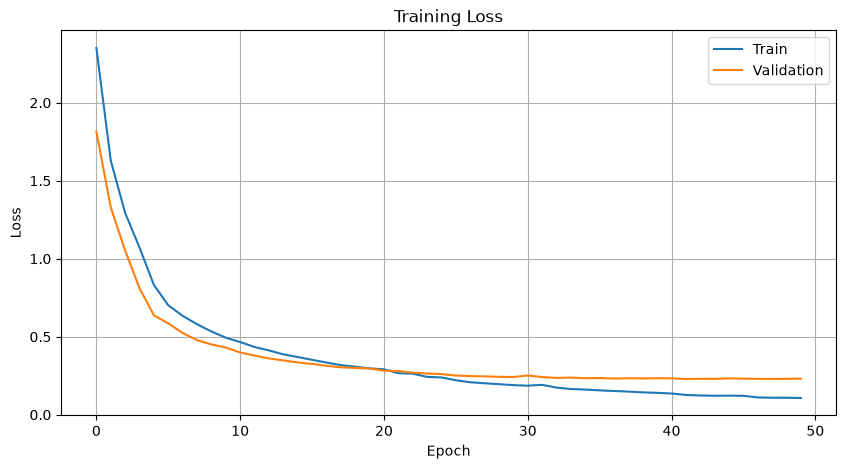

In [67]:
# ==========================================================
# Cell 33 - Training Curves
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(
    history["train_loss"],
    label="Train"
)

plt.plot(
    history["valid_loss"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.grid(True)

plt.show()

In [72]:
best_model = FormulaRecognizer().to(DEVICE)

checkpoint = torch.load(
    "checkpoints/best_model.pth",
    map_location=DEVICE,
    weights_only=False
)

best_model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [74]:
# ==========================================================
# Load Best Model (PyTorch 2.6+ Compatible)
# ==========================================================

import torch

best_model = FormulaRecognizer().to(DEVICE)

checkpoint = torch.load(
    "checkpoints/best_model.pth",
    map_location=DEVICE,
    weights_only=False      # Required because checkpoint contains Vocabulary object
)

# Print checkpoint contents
print("Checkpoint Keys:")
print(checkpoint.keys())

# Load model weights
best_model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_model.eval()

print("\n" + "="*60)
print("✅ Best Model Loaded Successfully!")
print("Epoch          :", checkpoint["epoch"] + 1)
print("Best Val Loss  :", checkpoint["best_val_loss"])
print("Device         :", next(best_model.parameters()).device)
print("="*60)

Checkpoint Keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_val_loss', 'vocab'])

✅ Best Model Loaded Successfully!
Epoch          : 42
Best Val Loss  : 0.2293324842571448
Device         : cuda:0


In [75]:
# ==========================================================
# Cell 35 - Test Evaluation
# ==========================================================

from tqdm.auto import tqdm

@torch.no_grad()
def evaluate_model(model, loader, criterion):

    model.eval()

    total_loss = 0
    total_token = 0
    total_exact = 0

    progress = tqdm(loader, desc="Testing")

    for images, formulas, lengths in progress:

        images = images.to(DEVICE, non_blocking=True)
        formulas = formulas.to(DEVICE, non_blocking=True)

        decoder_input = formulas[:, :-1]
        decoder_target = formulas[:, 1:]

        causal_mask = create_causal_mask(
            decoder_input.size(1)
        )

        padding_mask = (
            decoder_input == PAD_IDX
        )

        outputs = model(
            images,
            decoder_input,
            tgt_mask=causal_mask,
            tgt_padding_mask=padding_mask
        )

        loss = criterion(
            outputs.reshape(-1, len(vocab)),
            decoder_target.reshape(-1)
        )

        total_loss += loss.item()

        total_token += token_accuracy(
            outputs,
            decoder_target
        )

        total_exact += exact_match_accuracy(
            outputs,
            decoder_target
        )

    return (
        total_loss / len(loader),
        total_token / len(loader),
        total_exact / len(loader)
    )


# -----------------------------
# Run Test
# -----------------------------

test_loss, test_token, test_exact = evaluate_model(
    best_model,
    test_loader,
    criterion
)

print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)

print(f"Test Loss            : {test_loss:.4f}")
print(f"Test Token Accuracy  : {test_token:.2f}%")
print(f"Test Exact Accuracy  : {test_exact:.2f}%")

print("="*60)

Testing:   0%|          | 0/513 [00:00<?, ?it/s]


FINAL TEST RESULTS
Test Loss            : 0.2311
Test Token Accuracy  : 94.23%
Test Exact Accuracy  : 53.45%
